# Verify if the coupling with the film in the $v_1$ formula is negligible for large droplets

We consider the formula
$$\left( \int \frac{(\hat{h}_{0}^{in})^2}{Q_{0}^{in}}d\xi\right)\mathbf{v_{1}}=\left( -\nabla_{\chi}\int \hat{W}_{0}^{in}d\xi \right)+\left(\partial_{\chi}\partial_{h}W_{0}^{out}\int \hat{h}_{0}^{in}\frac{Q_{0}^{out}}{Q_{0}^{in}}d\xi \right)$$
where
$$Q=h^3/3\eta$$
$$W=A(\chi)w(h)-ch\chi;\quad \chi = \epsilon x$$
$$w(h)=h_a^3\frac15 h^{-5}-\frac12 h^{-2}$$
Then we can define
$$K= \int \frac{(\hat{h}_{0}^{in})^2}{(h_{0}^{in})^3}d\xi;\quad \hat{\Omega}=\int d\xi \hat{w}_{0}^{in};\quad m=\int d\xi \hat{h}_{0}^{in};\quad I=(h_{0}^{out})^3\int d\xi\frac{ \hat{h}_{0}^{in}}{(h_{0}^{in})^3}$$
and rewrite the formula as

$$(3\eta K) v_{1}= \left(-\nabla_{\chi}A\hat{\Omega} + c m \right)+ \left(  \nabla_{\chi}A w'_{out}I-cI \right)$$


# What changes if $\partial_{\chi}\partial_{h}W_0^{out}\to\nabla_{\chi}\partial_{h}W_0^{out}$?

$$\nabla_{\chi}\partial_{h}W_0^{out} = \partial_{\chi}\partial_{h}W_0^{out}+\partial_{hh}W_0^{out}\nabla_{\chi}h_0^{out}$$
so the additional term if $W=A(\chi)w(h);\quad \chi = \epsilon x$ would be
$$\partial_{hh}W_0^{out}\nabla_{\chi}h_0^{out}=w''_{out}A(\chi_*)\nabla_{\chi}h_0^{out}$$

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Continuation to compute h0in for different values of hmax or h0out
data = np.loadtxt(
    "1D_c0_continuation_22_04_26.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K = data[1:, numrows-1]
I = data[1:, numrows-2]
Omega = data[1:, numrows-3]
h0out_cont = data[1:, numrows-4]
hmax_cont = data[1:, numrows-6]
L = 50 # Size of the system
m = data[1:, numrows-7]*L   # concentration times size of the system gives mass
ha = np.mean(data[1:, numrows-8])   # It is a constant
def dwetting_pot(h):
        return (- ha**3*h**(-6) + h**(-3))
def ddwetting_pot(h):
        return (7*ha**3*h**(-7) - 3*h**(-4))


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1976456/2673167294.py:2: SyntaxWarning: invalid escape sequence '\O'
  plt.loglog(h0out_cont-ha,Omega,'.-',label="$\\hat{\Omega}$")


Text(0.5, 1.0, '$-\\nabla_{\\chi}\\int \\hat{W}_{0}^{in}d\\xi = -\\nabla_{\\chi}A\\hat{\\Omega} + c m $')

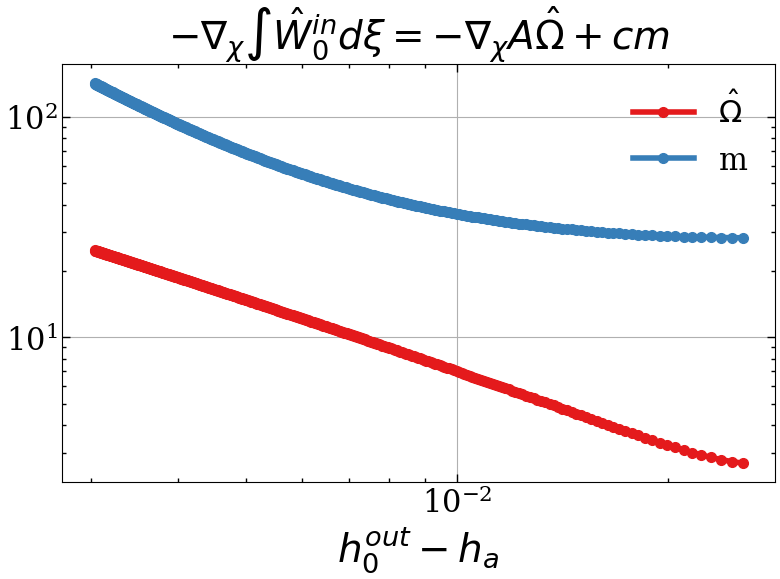

In [3]:
# Excess free energy
plt.loglog(h0out_cont-ha,Omega,'.-',label="$\\hat{\Omega}$")
plt.plot(h0out_cont-ha,m,'.-',label="m")
plt.xlabel('$h_0^{out}-h_a$')
plt.grid()
plt.legend()
plt.title('$-\\nabla_{\\chi}\\int \\hat{W}_{0}^{in}d\\xi = -\\nabla_{\\chi}A\\hat{\\Omega} + c m $')

Text(0.5, 1.0, "$\\nabla_{\\chi}\\partial_hW_{0}^{out}\\int \\hat{h}_{0}^{in}\\frac{Q_{0}^{out}}{Q_{0}^{in}}d\\xi = I\\left(  \\nabla_{\\chi}A w'_{out}-c\\right)$")

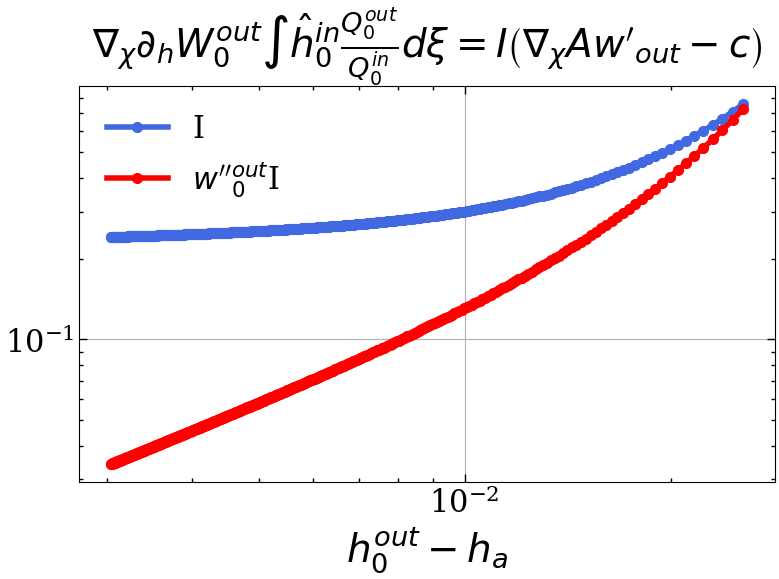

In [10]:
# Coupling with film
#plt.plot(h0out_cont-ha,ddwetting_pot(h0out_cont)*I,'.-',label="$w'_0^{out}$I")
plt.plot(h0out_cont-ha,I,'.-',label="I",color='royalblue')
plt.loglog(h0out_cont-ha,dwetting_pot(h0out_cont)*I,'.-',label="$w''_0^{out}$I",color='red')
plt.xlabel('$h_0^{out}-h_a$')
plt.grid()
plt.legend()
plt.title("$\\nabla_{\\chi}\\partial_hW_{0}^{out}\\int \\hat{h}_{0}^{in}\\frac{Q_{0}^{out}}{Q_{0}^{in}}d\\xi = I\\left(  \\nabla_{\\chi}A w'_{out}-c\\right)$")